# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



In [1]:
import numpy as np
import pandas as pd


In [2]:
# Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [3]:
# Look at the headers
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: n9mIdeuEvPojjpo1IEF9U//RvC7p0/W1AMoNDUbZLXx+hQbrQiDyTWkNDwxuxhkdvFoA0RgYqjA=
x-amz-request-id: ABRMVFTASRKYQRKY
Date: Wed, 15 Jul 2026 05:35:25 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [4]:
# Download the file
!curl -s -O {url}


In [5]:
# Verify
!ls -la


total 740
drwxr-xr-x 1 root root   4096 Jul 15 02:50 .
drwxr-xr-x 1 root root   4096 Jul 15 02:40 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 15 05:35 Spotify.csv


In [6]:
# Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n


     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## MAKING SINCE OF  DATA

In [7]:
spotify = pd.read_csv( url, index_col = 0 )
spotify

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D


In [8]:
spotify.transpose()

Index,1,2,3,4,5,6,7,8,9,10,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
Highest Charting Position,1,2,1,3,5,1,3,2,3,8,...,143,156,178,187,190,195,196,197,198,199
Number of Times Charted,8,3,11,5,1,18,16,10,8,10,...,1,1,1,1,1,1,1,1,1,1
Week of Highest Charting,2021-07-23--2021-07-30,2021-07-23--2021-07-30,2021-06-25--2021-07-02,2021-07-02--2021-07-09,2021-07-23--2021-07-30,2021-05-07--2021-05-14,2021-05-14--2021-05-21,2021-06-18--2021-06-25,2021-06-18--2021-06-25,2021-07-02--2021-07-09,...,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03,2019-12-27--2020-01-03
Song Name,Beggin',STAY (with Justin Bieber),good 4 u,Bad Habits,INDUSTRY BABY (feat. Jack Harlow),MONTERO (Call Me By Your Name),Kiss Me More (feat. SZA),Todo De Ti,Yonaguni,I WANNA BE YOUR SLAVE,...,JACKBOYS,Combatchy (feat. MC Rebecca),Old Town Road,Let Me Know (I Wonder Why Freestyle),Ne reviens pas,New Rules,Cheirosa - Ao Vivo,Havana (feat. Young Thug),Surtada - Remix Brega Funk,Lover (Remix) [feat. Shawn Mendes]
Streams,"48,633,449","47,248,719","40,162,559","37,799,456","33,948,454","30,071,134","29,356,736","26,951,613","25,030,128","24,551,591",...,"5,363,493","5,149,797","4,852,004","4,701,532","4,676,857","4,630,675","4,623,030","4,620,876","4,607,385","4,595,450"
Artist,Måneskin,The Kid LAROI,Olivia Rodrigo,Ed Sheeran,Lil Nas X,Lil Nas X,Doja Cat,Rauw Alejandro,Bad Bunny,Måneskin,...,JACKBOYS,"Anitta, Lexa, Luísa Sonza",Lil Nas X,Juice WRLD,"Gradur, Heuss L'enfoiré",Dua Lipa,Jorge & Mateus,Camila Cabello,"Dadá Boladão, Tati Zaqui, OIK",Taylor Swift
Artist Followers,3377762,2230022,6266514,83293380,5473565,5473565,8640063,6080597,36142273,3377762,...,437907,10741972,5488666,19102888,1390813,27167675,15019109,22698747,208630,42227614
Song ID,3Wrjm47oTz2sjIgck11l5e,5HCyWlXZPP0y6Gqq8TgA20,4ZtFanR9U6ndgddUvNcjcG,6PQ88X9TkUIAUIZJHW2upE,27NovPIUIRrOZoCHxABJwK,67BtfxlNbhBmCDR2L2l8qd,748mdHapucXQri7IAO8yFK,4fSIb4hdOQ151TILNsSEaF,2JPLbjOn0wPCngEot2STUS,4pt5fDVTg5GhEvEtlz9dKk,...,62zKJrpbLxz6InR3tGyr7o,2bPtwnrpFNEe8N7Q85kLHw,2YpeDb67231RjR0MgVLzsG,3wwo0bJvDSorOpNfzEkfXx,4TnFANpjVwVKWzkxNzIyFH,2ekn2ttSfGqwhhate0LSR0,2PWjKmjyTZeDpmOUa3a5da,1rfofaqEpACxVEHIZBJe6W,5F8ffc8KWKNawllr5WsW0r,3i9UVldZOE0aD0JnyfAZZ0
Genre,"['indie rock italiano', 'italian pop']",['australian hip hop'],['pop'],"['pop', 'uk pop']","['lgbtq+ hip hop', 'pop rap']","['lgbtq+ hip hop', 'pop rap']","['dance pop', 'pop']","['puerto rican pop', 'trap latino']","['latin', 'reggaeton', 'trap latino']","['indie rock italiano', 'italian pop']",...,"['rap', 'trap']","['funk carioca', 'funk pop', 'pagode baiano', ...","['lgbtq+ hip hop', 'pop rap']","['chicago rap', 'melodic rap']","['francoton', 'french hip hop', 'pop urbaine',...","['dance pop', 'pop', 'uk pop']","['sertanejo', 'sertanejo universitario']","['dance pop', 'electropop', 'pop', 'post-teen ...","['brega funk', 'funk carioca']","['pop', 'post-teen pop']"
Release Date,2017-12-08,2021-07-09,2021-05-21,2021-06-25,2021-07-23,2021-03-31,2021-04-09,2021-05-20,2021-06-04,2021-03-19,...,2019-12-27,2019-11-20,2019-06-21,2019-12-07,2019-11-29,2017-06-02,2019-10-11,2018-01-12,2019-09-25,2019-11-13


In [9]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Highest Charting Position  1556 non-null   int64 
 1   Number of Times Charted    1556 non-null   int64 
 2   Week of Highest Charting   1556 non-null   object
 3   Song Name                  1556 non-null   object
 4   Streams                    1556 non-null   object
 5   Artist                     1556 non-null   object
 6   Artist Followers           1556 non-null   object
 7   Song ID                    1556 non-null   object
 8   Genre                      1556 non-null   object
 9   Release Date               1556 non-null   object
 10  Weeks Charted              1556 non-null   object
 11  Popularity                 1556 non-null   object
 12  Danceability               1556 non-null   object
 13  Energy                     1556 non-null   object
 14  Loudness     

In [10]:
# there are no nulls
spotify.isna().sum().sort_values(ascending=False).mul(1)
# the reason for this is because they are all objects even if it has a space it claims it to be information

,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0
Release Date,0


In [11]:
nunique = spotify.nunique().sort_values( ascending = False )
nunique
# seems like columns 'song name', ' streams ', song ID '. are very high in non uniqueness meaning that they are identifiers.
# for this project since we are trying to predict what makes a popular song those columns will not help with testing and running a prediction model

,0
Streams,1556
Song Name,1556
Song ID,1517
Duration (ms),1486
Tempo,1461
Loudness,1394
Acousticness,965
Weeks Charted,775
Speechiness,772
Valence,732


In [12]:
# popularity id full of whole numbers yet it is an object. it is out target. lets convert to int.
#spotify['Popularity'] = pd.to_numeric(spotify['Popularity'], errors='coerce').astype(int)

# Verify the fix
#spotify['Popularity'].dtype

In [13]:
# was not able to be done yet lets convert all NAN and blank sopts into a 0

In [14]:
# Convert to numeric
spotify['Popularity'] = pd.to_numeric(spotify['Popularity'], errors='coerce')

# Fill any NaN values with 0, then cast to regular int **************
spotify['Popularity'] = spotify['Popularity'].fillna(0).astype(int)

# Verify the fix
print(spotify['Popularity'].dtype)

int64


In [15]:
print(spotify['Popularity'])

Index
1       100
2        99
3        99
4        98
5        96
       ... 
1552     79
1553     66
1554     81
1555     60
1556     70
Name: Popularity, Length: 1556, dtype: int64


In [16]:
spotify['Popularity'].isna().sum()
# of course non of them are gonna be NAN/nulls thats because I literally changed the value to 0 for those spots
# has 11 nulls im going to leave them alone since the quantity is so low
# instead I am going to convert the null values to zero

np.int64(0)

In [17]:
spotify['Popularity'] = spotify['Popularity'].fillna(0).astype(int)

In [18]:
spotify['Popularity'].isna().sum()

np.int64(0)

In [19]:
# this is also a 2nd target that I might be working with I am going to look at it aswell
print(spotify['Number of Times Charted'])

Index
1        8
2        3
3       11
4        5
5        1
        ..
1552     1
1553     1
1554     1
1555     1
1556     1
Name: Number of Times Charted, Length: 1556, dtype: int64


In [20]:
spotify['Number of Times Charted'].isna().sum()

np.int64(0)

In [21]:
#the number of Times Charted has no nulls

##*** Look into 'Population' class mates and profeessor say that there is a problem with it. re-evaluate the data.


## Data Cleaning 1

In [22]:
spotify_c = spotify.copy()

In [23]:
# dropping the following I determined them to be non important to predicticting a non-released song as a future hit song
# 'Artist' information is bias aswell as 'Artist Followers'
# Song Name, Song ID, Streams are identifiers
# Danceabillity is something that is recoreded after the fact of release not before so thats dropped. thats something that we can also try predicting not something thatll help us predict.

spotify_c = spotify_c.drop( columns = ['Song Name','Streams', 'Song ID', 'Danceability', 'Artist Followers', 'Artist', 'Release Date', 'Weeks Charted', 'Week of Highest Charting','Number of Times Charted', 'Highest Charting Position'])



In [24]:
spotify_c.shape

(1556, 11)

In [25]:
# I have a lot of Objects that I must change into floats. floats because they are nubers with decimals.
# some of those fields have information. those blank spots must be filled. and using gemini I found that I can use 'coerce'
spotify_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Genre          1556 non-null   object
 1   Popularity     1556 non-null   int64 
 2   Energy         1556 non-null   object
 3   Loudness       1556 non-null   object
 4   Speechiness    1556 non-null   object
 5   Acousticness   1556 non-null   object
 6   Liveness       1556 non-null   object
 7   Tempo          1556 non-null   object
 8   Duration (ms)  1556 non-null   object
 9   Valence        1556 non-null   object
 10  Chord          1556 non-null   object
dtypes: int64(1), object(10)
memory usage: 178.2+ KB


In [59]:
# Define the list of columns you want to change to float. chose those because they are decimal values
float_cols = [
    'Energy', 'Loudness', 'Speechiness', 'Acousticness',
    'Liveness', 'Tempo', 'Duration (ms)', 'Valence'
]

# 2. Convert them all to numeric floats
spotify_c[float_cols] = spotify_c[float_cols].apply(pd.to_numeric, errors='coerce')

# 3. Verify the changes
spotify_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Popularity     1556 non-null   int64  
 1   Energy         1545 non-null   float64
 2   Loudness       1545 non-null   float64
 3   Speechiness    1545 non-null   float64
 4   Acousticness   1545 non-null   float64
 5   Liveness       1545 non-null   float64
 6   Tempo          1545 non-null   float64
 7   Duration (ms)  1545 non-null   float64
 8   Valence        1545 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 153.9 KB


In [27]:
spotify_c.transpose()

Index,1,2,3,4,5,6,7,8,9,10,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
Genre,"['indie rock italiano', 'italian pop']",['australian hip hop'],['pop'],"['pop', 'uk pop']","['lgbtq+ hip hop', 'pop rap']","['lgbtq+ hip hop', 'pop rap']","['dance pop', 'pop']","['puerto rican pop', 'trap latino']","['latin', 'reggaeton', 'trap latino']","['indie rock italiano', 'italian pop']",...,"['rap', 'trap']","['funk carioca', 'funk pop', 'pagode baiano', ...","['lgbtq+ hip hop', 'pop rap']","['chicago rap', 'melodic rap']","['francoton', 'french hip hop', 'pop urbaine',...","['dance pop', 'pop', 'uk pop']","['sertanejo', 'sertanejo universitario']","['dance pop', 'electropop', 'pop', 'post-teen ...","['brega funk', 'funk carioca']","['pop', 'post-teen pop']"
Popularity,100,99,99,98,96,97,94,95,96,95,...,56,64,81,76,62,79,66,81,60,70
Energy,0.8,0.764,0.664,0.897,0.704,0.508,0.701,0.718,0.648,0.608,...,0.13,0.73,0.619,0.537,0.778,0.7,0.87,0.523,0.55,0.603
Loudness,-4.808,-5.484,-5.044,-3.712,-7.409,-6.682,-3.541,-3.605,-4.601,-4.008,...,-25.166,-3.032,-5.56,-7.895,-3.384,-6.021,-3.123,-4.333,-7.026,-7.176
Speechiness,0.0504,0.0483,0.154,0.0348,0.0615,0.152,0.0286,0.0506,0.118,0.0387,...,0.0336,0.0809,0.102,0.0832,0.0638,0.0694,0.0851,0.03,0.0587,0.064
Acousticness,0.127,0.0383,0.335,0.0469,0.0203,0.297,0.235,0.31,0.276,0.00165,...,0.9,0.383,0.0533,0.172,0.212,0.00261,0.24,0.184,0.249,0.433
Liveness,0.359,0.103,0.0849,0.364,0.0501,0.384,0.123,0.0932,0.135,0.178,...,0.111,0.0197,0.113,0.418,0.168,0.153,0.333,0.132,0.182,0.0862
Tempo,134.002,169.928,166.928,126.026,149.995,178.818,110.968,127.949,179.951,132.507,...,123.342,150.134,136.041,125.028,124.996,116.073,152.37,104.988,154.064,205.272
Duration (ms),211560.0,141806.0,178147.0,231041.0,212000.0,137876.0,208867.0,199604.0,206710.0,173347.0,...,46837.0,157600.0,157067.0,215381.0,188613.0,209320.0,181930.0,217307.0,152784.0,221307.0
Valence,0.589,0.478,0.688,0.591,0.894,0.758,0.742,0.342,0.44,0.958,...,0.0676,0.605,0.639,0.383,0.933,0.608,0.714,0.394,0.881,0.422


In [28]:
# ill be dropping the objects just so I can work with numbers to be able to do linear transgression and/or naive bayes
# ill include the objects later to see what happens

In [29]:
spotify_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Genre          1556 non-null   object 
 1   Popularity     1556 non-null   int64  
 2   Energy         1545 non-null   float64
 3   Loudness       1545 non-null   float64
 4   Speechiness    1545 non-null   float64
 5   Acousticness   1545 non-null   float64
 6   Liveness       1545 non-null   float64
 7   Tempo          1545 non-null   float64
 8   Duration (ms)  1545 non-null   float64
 9   Valence        1545 non-null   float64
 10  Chord          1556 non-null   object 
dtypes: float64(8), int64(1), object(2)
memory usage: 178.2+ KB


In [30]:
# will delete Genre and Chord rows
spotify_c = spotify_c.drop( columns = ['Genre', 'Chord'])

In [31]:
spotify_c.shape

(1556, 9)

## Data Cleaning 2

In [32]:
spotify_c2 = spotify.copy()

In [33]:
# dropping the following I determined them to be non important to predicticting a non-released song as a future hit song
# drop 'Artist' information is bias aswell as
# Keep 'Artist Followers'this time around
# drop Song Name, Song ID, Streams are identifiers
# drop Danceabillity,'Weeks Charted', 'Week of Highest Charting' aftermath of popularity
# drop Highest Charting Position and Number of Times Charted aftermath
spotify_c2 = spotify.drop( columns = ['Song Name','Streams','Chord','Genre', 'Song ID', 'Danceability', 'Artist', 'Release Date', 'Weeks Charted', 'Week of Highest Charting', 'Highest Charting Position', 'Number of Times Charted'])


In [34]:
spotify_c2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Artist Followers  1556 non-null   object
 1   Popularity        1556 non-null   int64 
 2   Energy            1556 non-null   object
 3   Loudness          1556 non-null   object
 4   Speechiness       1556 non-null   object
 5   Acousticness      1556 non-null   object
 6   Liveness          1556 non-null   object
 7   Tempo             1556 non-null   object
 8   Duration (ms)     1556 non-null   object
 9   Valence           1556 non-null   object
dtypes: int64(1), object(9)
memory usage: 166.0+ KB


In [35]:
#turn objects into floats or int
float_cols = [
    'Energy', 'Loudness', 'Speechiness', 'Acousticness',
    'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers'
]

# 2. Convert them all to numeric floats
spotify_c2[float_cols] = spotify_c2[float_cols].apply(pd.to_numeric, errors='coerce')

# 3. Verify the changes
spotify_c2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist Followers  1545 non-null   float64
 1   Popularity        1556 non-null   int64  
 2   Energy            1545 non-null   float64
 3   Loudness          1545 non-null   float64
 4   Speechiness       1545 non-null   float64
 5   Acousticness      1545 non-null   float64
 6   Liveness          1545 non-null   float64
 7   Tempo             1545 non-null   float64
 8   Duration (ms)     1545 non-null   float64
 9   Valence           1545 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 166.0 KB


In [36]:
spotify_c2.isna().sum()

,0
Artist Followers,11
Popularity,0
Energy,11
Loudness,11
Speechiness,11
Acousticness,11
Liveness,11
Tempo,11
Duration (ms),11
Valence,11


In [37]:
# convert nulls to 0
spotify_c2[float_cols] = spotify_c2[float_cols].fillna(0)

In [38]:
spotify_c2.isna().sum()

,0
Artist Followers,0
Popularity,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Tempo,0
Duration (ms),0
Valence,0


## Data Cleaning 3 attempt
In this attempt I will changing my target to "Number of Times Charted" instead ot "popularity" my assupmtion is it there are more than 1 instance of a song being in the top charts the popularity will be high because more people are listining to it making a song timeless and not a 1 hit number/outliar. the songs with the most high chart # of precense are the ones that will beat and other things will have a greater affect. thoughts willl be clearer as we look at data.

In [39]:
spotify_c3 = spotify.copy()

In [40]:

spotify_c3 = spotify_c3.drop( columns = ['Streams', 'Song Name', 'Song ID', 'Danceability', 'Artist', 'Release Date', 'Highest Charting Position', 'Week of Highest Charting', 'Genre', 'Chord', 'Weeks Charted','Artist Follo'])



In [41]:
spotify_c3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Number of Times Charted  1556 non-null   int64 
 1   Artist Followers         1556 non-null   object
 2   Popularity               1556 non-null   int64 
 3   Energy                   1556 non-null   object
 4   Loudness                 1556 non-null   object
 5   Speechiness              1556 non-null   object
 6   Acousticness             1556 non-null   object
 7   Liveness                 1556 non-null   object
 8   Tempo                    1556 non-null   object
 9   Duration (ms)            1556 non-null   object
 10  Valence                  1556 non-null   object
dtypes: int64(2), object(9)
memory usage: 178.2+ KB


In [42]:
spotify_c3.transpose()

Index,1,2,3,4,5,6,7,8,9,10,...,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556
Number of Times Charted,8,3,11,5,1,18,16,10,8,10,...,1,1,1,1,1,1,1,1,1,1
Artist Followers,3377762,2230022,6266514,83293380,5473565,5473565,8640063,6080597,36142273,3377762,...,437907,10741972,5488666,19102888,1390813,27167675,15019109,22698747,208630,42227614
Popularity,100,99,99,98,96,97,94,95,96,95,...,56,64,81,76,62,79,66,81,60,70
Energy,0.8,0.764,0.664,0.897,0.704,0.508,0.701,0.718,0.648,0.608,...,0.13,0.73,0.619,0.537,0.778,0.7,0.87,0.523,0.55,0.603
Loudness,-4.808,-5.484,-5.044,-3.712,-7.409,-6.682,-3.541,-3.605,-4.601,-4.008,...,-25.166,-3.032,-5.56,-7.895,-3.384,-6.021,-3.123,-4.333,-7.026,-7.176
Speechiness,0.0504,0.0483,0.154,0.0348,0.0615,0.152,0.0286,0.0506,0.118,0.0387,...,0.0336,0.0809,0.102,0.0832,0.0638,0.0694,0.0851,0.03,0.0587,0.064
Acousticness,0.127,0.0383,0.335,0.0469,0.0203,0.297,0.235,0.31,0.276,0.00165,...,0.9,0.383,0.0533,0.172,0.212,0.00261,0.24,0.184,0.249,0.433
Liveness,0.359,0.103,0.0849,0.364,0.0501,0.384,0.123,0.0932,0.135,0.178,...,0.111,0.0197,0.113,0.418,0.168,0.153,0.333,0.132,0.182,0.0862
Tempo,134.002,169.928,166.928,126.026,149.995,178.818,110.968,127.949,179.951,132.507,...,123.342,150.134,136.041,125.028,124.996,116.073,152.37,104.988,154.064,205.272
Duration (ms),211560,141806,178147,231041,212000,137876,208867,199604,206710,173347,...,46837,157600,157067,215381,188613,209320,181930,217307,152784,221307


In [43]:
# have to change my objects to floats or ints
float_cols = [
    'Energy', 'Loudness', 'Speechiness', 'Acousticness',
    'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers'
]

# 2. Convert them all to numeric floats
spotify_c3[float_cols] = spotify_c3[float_cols].apply(pd.to_numeric, errors='coerce')

# 3. Verify the changes
spotify_c3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number of Times Charted  1556 non-null   int64  
 1   Artist Followers         1545 non-null   float64
 2   Popularity               1556 non-null   int64  
 3   Energy                   1545 non-null   float64
 4   Loudness                 1545 non-null   float64
 5   Speechiness              1545 non-null   float64
 6   Acousticness             1545 non-null   float64
 7   Liveness                 1545 non-null   float64
 8   Tempo                    1545 non-null   float64
 9   Duration (ms)            1545 non-null   float64
 10  Valence                  1545 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 178.2 KB


In [44]:
spotify_c3.isna().sum()

,0
Number of Times Charted,0
Artist Followers,11
Popularity,0
Energy,11
Loudness,11
Speechiness,11
Acousticness,11
Liveness,11
Tempo,11
Duration (ms),11


In [45]:
#lets convert those nulls to zero so they dont miss up data
spotify_c3[float_cols] = spotify_c3[float_cols].fillna(0)

In [46]:
spotify_c3.isna().sum()

,0
Number of Times Charted,0
Artist Followers,0
Popularity,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Tempo,0
Duration (ms),0


# Heat Map/ Correlation

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

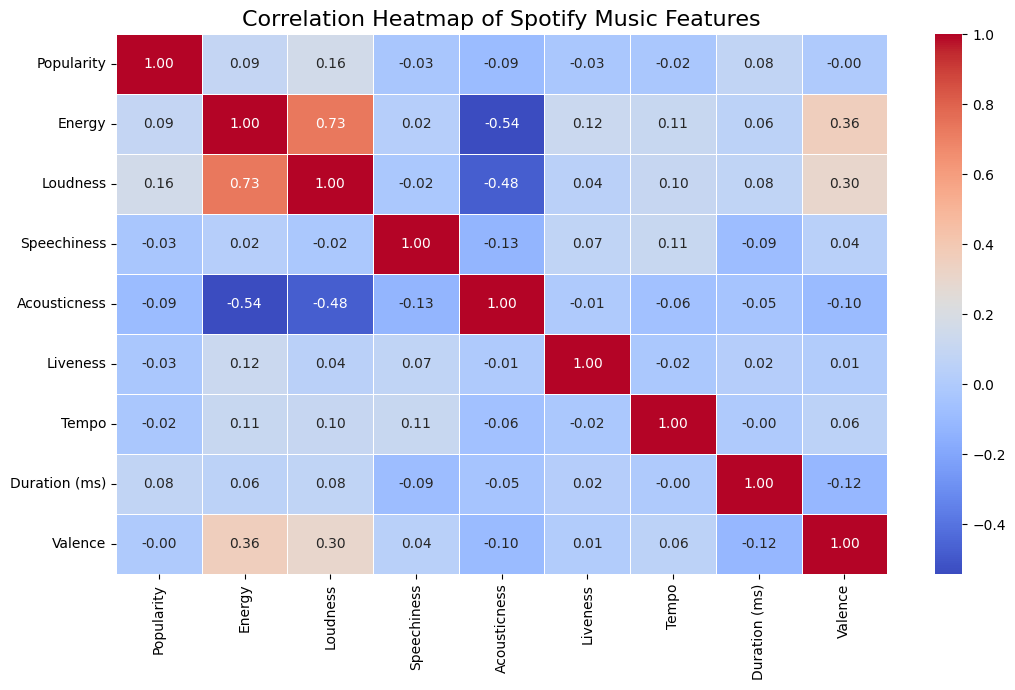

In [76]:
# 1. Select only the numeric columns (including your target 'Popularity')
# This automatically drops 'Genre' and 'Chord' so the correlation works perfectly.
numeric_spotify = spotify_c.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_spotify.corr()

# 3. Set up the matplotlib figure size
plt.figure(figsize=(11, 7))

# 4. Create the heatmap
# 'annot=True' displays the numbers inside each square
# 'cmap="coolwarm"' gives a nice blue (negative) to red (positive) color scheme
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# 5. Add titles and show the plot
plt.title("Correlation Heatmap of Spotify Music Features", fontsize=16)
plt.tight_layout()
plt.show()

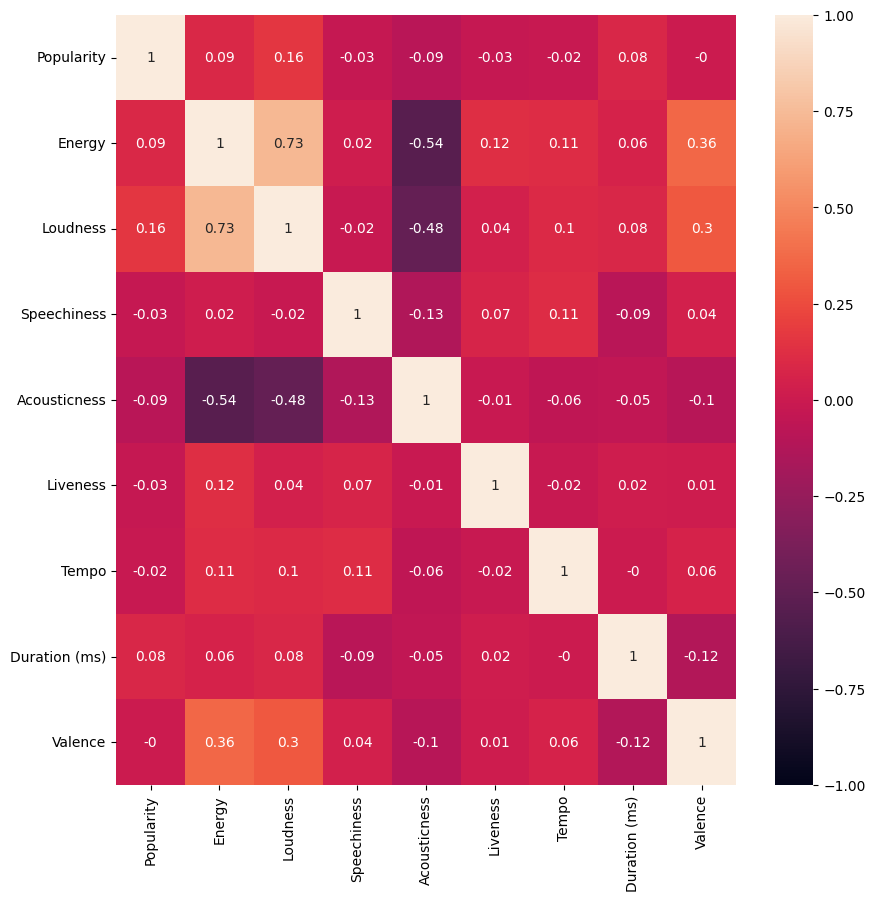

In [49]:
plt.figure(figsize=(10,10))
correlation_matrix = spotify_c.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, vmin=-1, vmax=1) ;

In [50]:
# im gonna have to re-evaluate my picks
# everything has very little effect on the popularity

## Corr Heat map 2

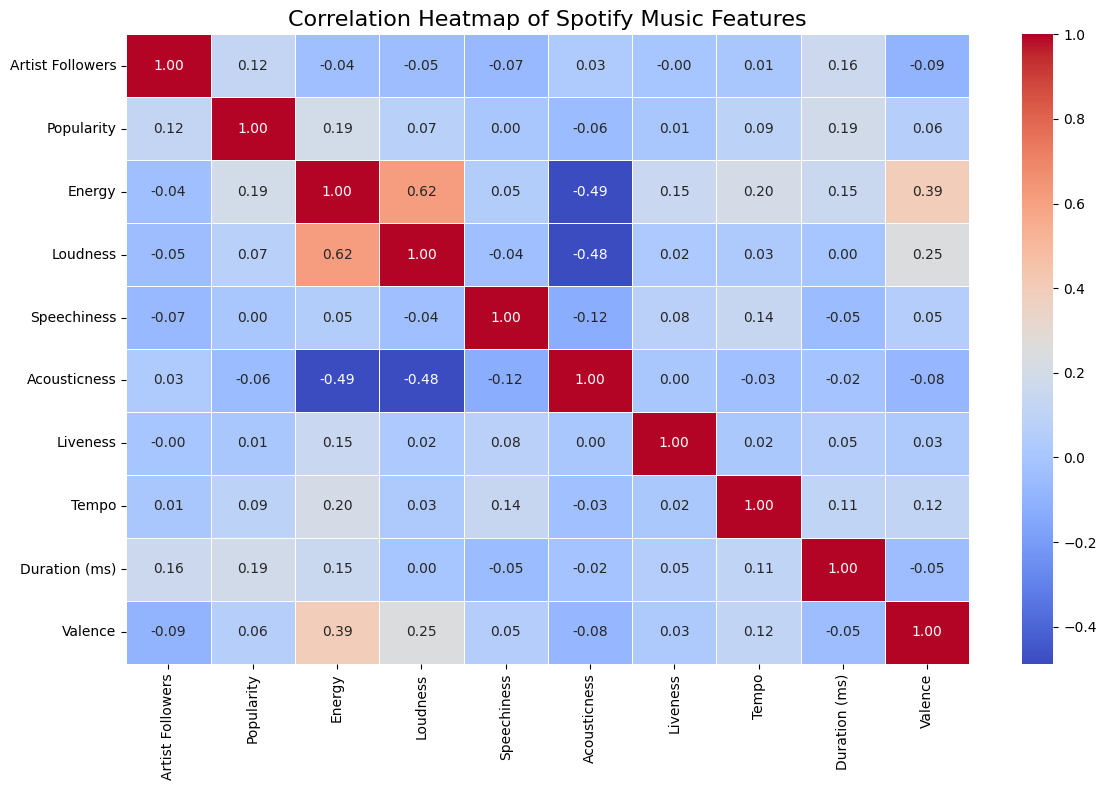

In [51]:
numeric_spotify = spotify_c2.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_spotify.corr()

# 3. Set up the matplotlib figure size
plt.figure(figsize=(12, 8))

# 4. Create the heatmap
# 'annot=True' displays the numbers inside each square
# 'cmap="coolwarm"' gives a nice blue (negative) to red (positive) color scheme
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.6)

# 5. Add titles and show the plot
plt.title("Correlation Heatmap of Spotify Music Features", fontsize=16)
plt.tight_layout()
plt.show()

## Corr HeatMap 3

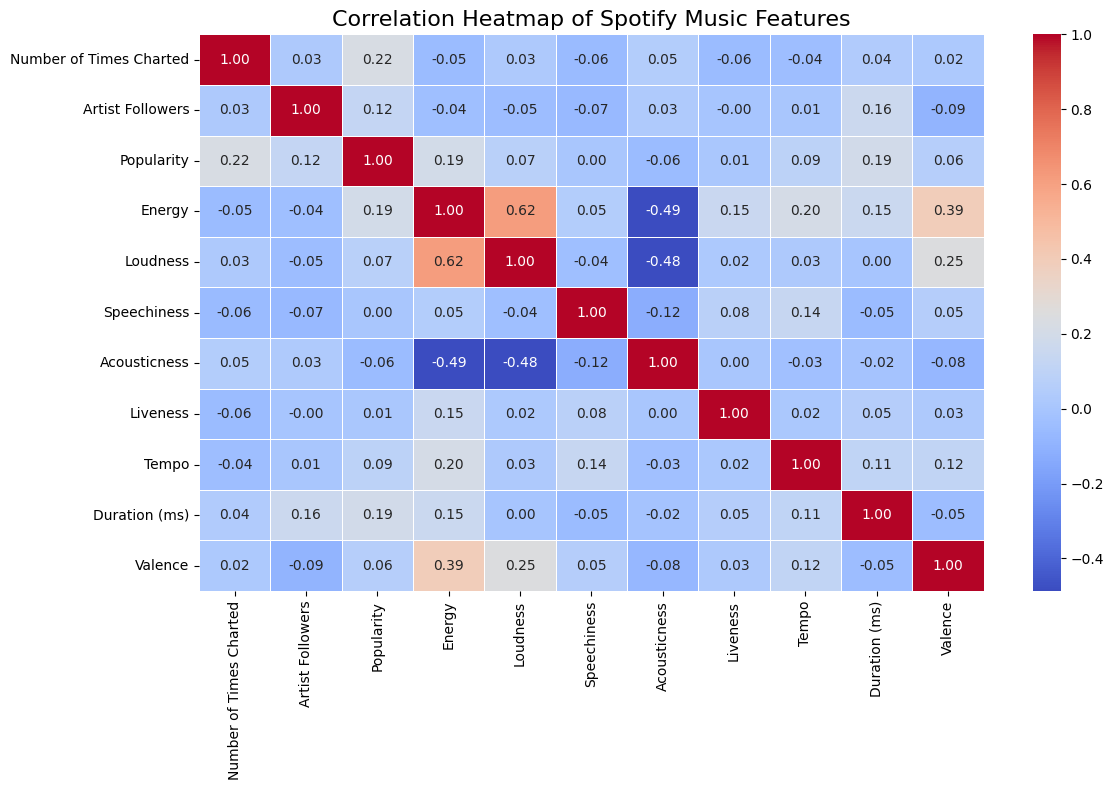

In [52]:
# 1. Select ALL numeric columns (this grabs both floats and ints automatically)
numeric_spotify = spotify_c3.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
corr_matrix3 = numeric_spotify.corr()

# 3. Set up the matplotlib figure size (12x8 is great to fit all features)
plt.figure(figsize=(12, 8))

# 4. Create the heatmap
# 'annot=True' displays the numbers inside each square
# 'cmap="coolwarm"' gives a nice blue (negative) to red (positive) color scheme
sns.heatmap(corr_matrix3, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.6)

# 5. Add titles and show the plot
plt.title("Correlation Heatmap of Spotify Music Features", fontsize=16)
plt.tight_layout()
plt.show()

##Linear Regression or tree-based regression

In [53]:
#im gonna use linear regression first then the tree-based

linear Regression

In [54]:
import matplotlib.pyplot as plt

In [55]:
spotify_linear = spotify_c.copy()

In [56]:
# after running it once Gemini and I figured out that another thing I should take out is
# Highest Charting Position Number of Times Charted
# these are the aftermath of a release which we are trying to predict before the release

In [57]:
spotify_linear.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Popularity     1556 non-null   int64  
 1   Energy         1545 non-null   float64
 2   Loudness       1545 non-null   float64
 3   Speechiness    1545 non-null   float64
 4   Acousticness   1545 non-null   float64
 5   Liveness       1545 non-null   float64
 6   Tempo          1545 non-null   float64
 7   Duration (ms)  1545 non-null   float64
 8   Valence        1545 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 153.9 KB


In [58]:
spotify_linear.drop( columns = ['Highest Charting Position', 'Number of Times Charted'])

KeyError: "['Highest Charting Position', 'Number of Times Charted'] not found in axis"

In [ ]:
fig, axs = plt.subplots(3,5, figsize = (20,12))
column_names = spotify_linear.columns
n = 0
for i in range(3): # Loop through rows
  for j in range(5): # Loop through columns
    axs[i,j].hist(spotify_linear[column_names[n]])
    axs[i,j].set_xlabel(column_names[n])
    axs[i,j].set_ylabel('Count')
    n = n + 1

hist knowledge
1. Postive Skew - speechiness, Acousticness, liveness. duration is kind of skewed

2. Negative Skew - loudness and energy

3. normally Distrubuted - valence, tempo

4. weird - Highest charting position

In [ ]:
#Lets fix the positive skews to be more normal distrubuted
#log transformation
# never mind found out that I dont have to


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [78]:
# with the help of Gemini the following was made

#***

In [79]:
# 1. Clean up the 11 missing rows (NaN values) caused by errors='coerce'
spotify_linear = spotify_c.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'])

# 2. Select your continuous numeric features (X) and your target (y)
# (Note: We exclude 'Genre' and 'Chord' for now because they are still objects/text)
feature_cols = [ 'Energy','Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)']

X = spotify_linear[feature_cols]
y = spotify_linear['Popularity']

# 3. Split the data into a training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 4. Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions and evaluate your model
y_pred = lr_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): 16.3419
R-squared (R2 Score): -0.0178


In [80]:
# Base Line subsets -'Energy', 'Loudness', 'Speechiness', 16.4795'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'])
# Attempt of testing 1:
# RMSE 16.3388 (R_squared -0.0174)

# Attempt of testing 2: -energy - error went hire I should keep this but R2 is terrible
# (RMSE): 16.2950 (R2 Score): -0.0119

# Attempt of testing 3: - Loudness (RMSE): 16.2318 (R2 Score): -0.0041

#Attempt of testing 4: - speechness  (RMSE): 16.3363  (R2 Score): -0.0171

#Attempt of testing 5: - Acousticness (RMSE): 16.3027 (R2 Score): -0.0129

#Attempt of testing 6: - Liveness (RMSE): 16.3491 (R2 Score): -0.0187

#Attempt of testing 7: - Tempo (RMSE): 16.3397 (R2 Score): -0.0175

#Attempt of testing 8: - Duration (RMSE): 16.3477 (R2 Score): -0.0185

#Attempt of Testing 9: - Valence (RMSE): 16.3419  (R2 Score): -0.0178

In [81]:
#Linear Regression graph

##Linear Regression 2

In [82]:
# 1. Clean up the 11 missing rows (NaN values) caused by errors='coerce'
spotify_linear2 = spotify_c2.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers'])

# 2. Select your continuous numeric features (X) and your target (y)
# (Note: We exclude 'Genre' and 'Chord' for now because they are still objects/text)
feature_cols = [ 'Energy','Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Artist Followers']

X = spotify_linear2[feature_cols]
y = spotify_linear2['Popularity']

# 3. Split the data into a training set (73%) and testing set (27%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.27, random_state=42)

# 4. Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions and evaluate your model
y_pred = lr_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): 15.2962
R-squared (R2 Score): 0.1025


In [ ]:
#adding artist Followers made all the difference

## linear Regression 3

In [ ]:
# 1. Clean up the 11 missing rows (NaN values) caused by errors='coerce'
spotify_linear3 = spotify_c3.dropna(subset=[ 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers' ])

# 2. Select your continuous numeric features (X) and your target (y)
# (Note: We exclude 'Genre' and 'Chord' for now because they are still objects/text)
feature_cols = [  'Energy','Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)','Artist Followers' ]

X = spotify_linear3[feature_cols]
y = spotify_linear3['Number of Times Charted']

# 3. Split the data into a training set (73%) and testing set (27%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.27, random_state=42)

# 4. Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions and evaluate your model
y_pred = lr_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

In [ ]:
#RMSE - 16.2845 R2 - .0160
# + Artist Followers - 16.3327 R2 0.0102

# Treee Based Regression

In [65]:
spotify_tree = spotify_c.copy()

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [83]:
spotify_tree.drop( columns = ['Highest Charting Position', 'Number of Times Charted'])

KeyError: "['Highest Charting Position', 'Number of Times Charted'] not found in axis"

In [84]:
# Generated with Gemini

In [85]:
# 1. Drop the 11 rows with missing values (NaNs) from your copy
spotify_tree = spotify_tree.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'])

# 2. Select your continuous numeric features (X) and target (y)
feature_cols = ['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']
X = spotify_tree[feature_cols]
y = spotify_tree['Popularity']

# 3. Split the data (80% train, 20% test) using the same random state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.49, random_state=42)

# 4. Initialize the Decision Tree Regressor
# We set max_depth=5 to start simple and prevent the tree from overfitting immediately
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)

# 5. Fit the model on the training data
tree_model.fit(X_train, y_train)

# 6. Make predictions and evaluate
y_pred = tree_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree RMSE: {rmse:.4f}")
print(f"Decision Tree R-squared (R2 Score): {r2:.4f}")

Decision Tree RMSE: 16.7619
Decision Tree R-squared (R2 Score): -0.0583


In [ ]:
# getting the CV RMSE
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}")


In [ ]:
#I am trying a Random Forrest to see if I get better results

In [86]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
# 1. Clean up missing rows from your dataset copy
spotify_rf = spotify_c.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'])

# 2. Select ONLY features a brand new song would have before release
feature_cols = ['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']
X = spotify_rf[feature_cols]
y = spotify_rf['Popularity']

# 3. Split the data using the exact same random state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the Random Forest Regressor
# n_estimators=100 means we are building 100 trees together
# max_depth=6 keeps individual trees from overfitting
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

# 5. Fit the forest model
rf_model.fit(X_train, y_train)

# 6. Make predictions and evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R-squared (R2 Score): {r2:.4f}")

Random Forest RMSE: 17.0016
Random Forest R-squared (R2 Score): -0.0749


In [ ]:
# not even that helped

## tree regression 2

In [88]:
spotify_tree2 = spotify_c2.copy()

In [89]:
# 1. Clean up missing rows from your dataset copy
spotify_rf = spotify_c2.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers'])

# 2. Select ONLY features a brand new song would have before release
feature_cols = ['Energy', 'Loudness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers']
X = spotify_rf[feature_cols]
y = spotify_rf['Popularity']

# 3. Split the data using the exact same random state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the Random Forest Regressor
# n_estimators=100 means we are building 100 trees together
# max_depth=6 keeps individual trees from overfitting
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

# 5. Fit the forest model
rf_model.fit(X_train, y_train)

# 6. Make predictions and evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R-squared (R2 Score): {r2:.4f}")

Random Forest RMSE: 10.0566
Random Forest R-squared (R2 Score): 0.6113


In [ ]:
#RMSE 10.0961 R^2 - 0.6082
# - Speechniess 10.0566 R^2 0.6113

## Tree Regression 3

In [90]:
spotify_tree3 = spotify_c3.copy()

In [91]:
# 1. Clean up missing rows from your dataset copy
spotify_rf = spotify_c3.dropna(subset=['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers'])

# 2. Select ONLY features a brand new song would have before release
feature_cols = ['Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Artist Followers']
X = spotify_rf[feature_cols]
y = spotify_rf['Number of Times Charted']

# 3. Split the data using the exact same random state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the Random Forest Regressor
# n_estimators=100 means we are building 100 trees together
# max_depth=6 keeps individual trees from overfitting
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

# 5. Fit the forest model
rf_model.fit(X_train, y_train)

# 6. Make predictions and evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest R-squared (R2 Score): {r2:.4f}")

Random Forest RMSE: 16.6116
Random Forest R-squared (R2 Score): 0.0116
